## Statistical Functions Tutorial

In this tutorial, we will explore (with **kea**) using statistical functions (structure function and correlation function) on the synthetic fields.

First, import **kea** and generate a field.

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
# modify_latex_rc()
# modify_latex_rc()

from kea.simulator import make_field

# Set number of grid points
N = 1024
# Number of dimensions (two-dimensional)
D = 2
# We have the same number of grid points in each dimension
grid_dims = (N,N)

# Make the field
field = make_field(grid_dims,
                   spectrum_kwargs={'powerlaw': -8./3., 'cutoff_scale': 5.},
                   spectrum_function='cutoff_powerlaw',
                   seed=1, normalize_output=True)

The statistical functions we are going to explore can be computationally intense to generate (for large data). **kea** provides the option to switch to using the GPU for some computations. If you have a good enough GPU, it is recommended you do this as it can drastically reduce computation time.

Otherwise, comment out the following block and continue using the CPU (which is the default behaviour).

In [2]:
from kea.utils import set_calculation_mode
set_calculation_mode(use_cpu=False, use_gpu=True)

Set statistic function calculation flags: (<CalculationMode.USE_GPU: 1>,)


(<CalculationMode.USE_GPU: 1>,)

### Correlation functions

We will start with the correlation functions, $R(r)$ which depends on the physical lag-distance $r$.

In [3]:
from kea.statistics.statfunc import partial_correlation_function, complete_symmetric_correlation_function

First, we will call `partial_correlation_function()` and provide it the field. Most of the other parameters are assumed to be default.

This function evaluates the correlation function for each lag distance/vector and returns the result along with the list of vectors.

(262144, 2) (262144, 1)
(512, 512)


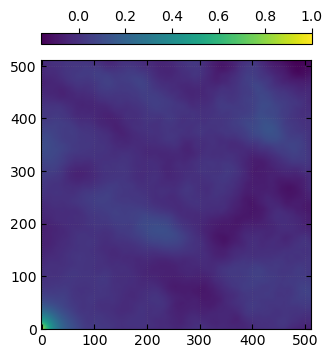

In [4]:
# Evaluate the correlation function
lags, partial_acf = partial_correlation_function(field)
print(np.shape(lags), np.shape(partial_acf))

# The function is returned as a 1D array corresponding to the lag-vectors in `lags`
# If we wish to view this nicely, we convert into the 2D form.
partial_acf = partial_acf.reshape((N//2, N//2))
# Reshape the list of lags to give a 2D array of lag-vector magnitudes
partial_lags = np.linalg.norm(lags, axis=1).reshape((N//2, N//2))
print(np.shape(partial_acf))

## Plot the 2D ACF
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(partial_acf, cmap='viridis', origin='lower')
pretty_axes(ax)
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')

Note that the lags are positive only. If you want to get the correlation function for "_all_" lags, we will need to use `complete_symmetric_correlation_function()`. This function intelligently computes _half_ the domain and then stitches it all together assuming symmetry.

Notice that shape returned from `complete_symmetric_correlation_function()` is different from `partial_correlation_function()` and doesn't need to be reshaped for plotting as 2D.

(1024, 1024, 2) (1024, 1024)


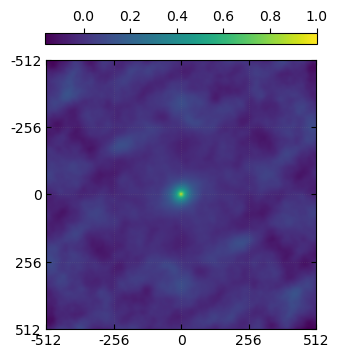

In [5]:
# Evaluate the correlation function
complete_lags, complete_acf = complete_symmetric_correlation_function(field)
print(np.shape(complete_lags), np.shape(complete_acf))

## Plot the 2D ACF
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(complete_acf, cmap='viridis')
pretty_axes(ax)
ax.set_xticks(*make_ax_step(N, N//4))
ax.set_yticks(*make_ax_step(N, N//4))
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')

It can be a bit difficult to do analysis on the 2D domain. Thus, we reduce the dimensionality by _averaging_ circular shells of (binned) constant magnitude. **kea** provides these binning routines.

If we bin both the partial and complete ACFs, we see they are almost identical with discrepancies that are resultant from the statistics of having more data to average over in the complete (the partial has 1/4 as much information).

Text(0, 0.5, 'ACF, $R(r)$')

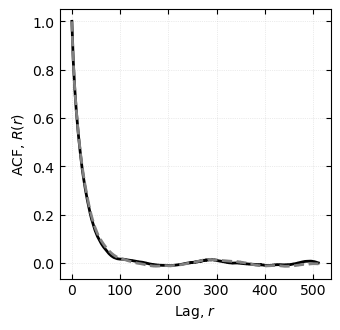

In [6]:
from kea.utils import binning

bins_partial, binned_acf_partial, bin_widths = binning.bin_data(
    partial_lags, partial_acf, bin_func=np.nanmean, cut_excess=True)

bins_full, binned_acf_full, bin_widths_full = binning.bin_data(
    np.linalg.norm(complete_lags, axis=-1), complete_acf, bin_func=np.nanmean, cut_excess=True)

# Plot binned ACF
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(bins_partial, binned_acf_partial, linestyle='-', color='black', linewidth=2.)
ax.plot(bins_full, binned_acf_full, linestyle='--', color='gray', linewidth=2.)
pretty_axes(ax)
ax.set_xlabel('Lag, $r$')
ax.set_ylabel('ACF, $R(r)$')

### Structure functions

Next, we will compute the structure function $SF(r)$ which also depends on the lag distance $r$ and thus shares a lot of code with the ACF.

In [7]:
from kea.statistics.statfunc import structure_function

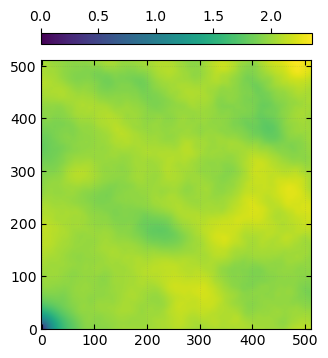

In [8]:
lags, sf = structure_function(field)
sf = np.reshape(sf, (N//2, N//2))

## Plot the 2D ACF
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(sf, cmap='viridis', origin='lower')
pretty_axes(ax)
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')

Similarly to the ACF, we can bin the SF.

We can also compare the directly computed SF to the ACF using the relation:
$$
SF(r) = 2R(0) - 2R(r)
$$

Text(0, 0.5, 'Structure function, $SF(r)$')

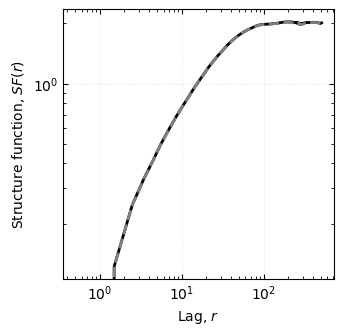

In [9]:
from kea.utils import binning

# Bin the SF
bins_sf, binned_sf, _ = binning.bin_data(
    np.linalg.norm(lags, axis=1).reshape((N//2, N//2)), sf, bin_func=np.nanmean, cut_excess=True)

## Estimate the SF using the ACF
sf_from_acf = 2.*binned_acf_partial[0] - 2.*binned_acf_partial

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(bins_sf, binned_sf, linestyle='-', color='black', linewidth=2.)
ax.plot(bins_partial, sf_from_acf, linestyle='--', color='gray', linewidth=2.)
pretty_axes(ax)
ax.loglog()
ax.set_xlabel('Lag, $r$')
ax.set_ylabel('Structure function, $SF(r)$')

Structure functions also generalize to higher-orders. We can calculate these by providing the `order` parameter in `structure_function()`. Note that the shape is now larger to account for the information corresponding to both the orders we requested.

In [10]:
## For example, compute the 4-th and 5-th order SF
lags_45, sf_45 = structure_function(field, orders=(4,5))
print(np.shape(sf_45))
sf_45 = np.reshape(sf_45, (N//2, N//2, 2))
print(np.shape(sf_45))

(262144, 2)
(512, 512, 2)


Text(0, 0.5, 'Structure function, $SF(r)$')

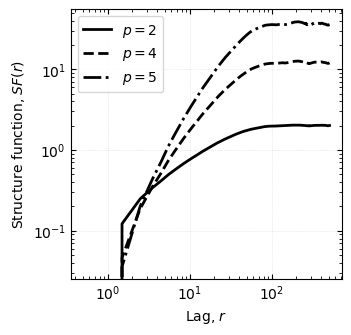

In [11]:
from kea.utils import binning

# Bin the 4-th and 5-th orders
bins_sf4, binned_sf4, _ = binning.bin_data(
    np.linalg.norm(lags, axis=1).reshape((N//2, N//2)), sf_45[:,:,0], bin_func=np.nanmean, cut_excess=True)
bins_sf5, binned_sf5, _ = binning.bin_data(
    np.linalg.norm(lags, axis=1).reshape((N//2, N//2)), sf_45[:,:,1], bin_func=np.nanmean, cut_excess=True)

## Plot all computed orders (2,4,5)
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(bins_sf, binned_sf, linestyle='-', color='black', linewidth=2., label='$p=2$')
ax.plot(bins_sf4, binned_sf4, linestyle='--', color='black', linewidth=2., label='$p=4$')
ax.plot(bins_sf5, binned_sf5, linestyle='-.', color='black', linewidth=2., label='$p=5$')
ax.legend()
pretty_axes(ax)
ax.loglog()
ax.set_xlabel('Lag, $r$')
ax.set_ylabel('Structure function, $SF(r)$')